## Institutional Holdings 

Rong Wang, June 2026 

In [1]:
# Packages
import pandas as pd
import numpy as np
import datetime as dt
from pandas.tseries.offsets import *
import matplotlib.pyplot as plt
from pathlib import Path

# Define directories
datapath = Path("/work/rw196/holdings")

### Build the Full Dataset

##### WRDS SEC 13F (2013Q2 - 2025Q4)

In [ ]:
# %%time
# # Load sas data
# wrdssec = pd.read_sas(datapath/"WRDS_SEC_2013_2025.sas7bdat", format="sas7bdat")

# # Convert to Parquet for future use
# wrdssec.to_parquet(datapath/"WRDS_SEC_2013_2025.parquet")
# wrdssec = wrdssec.rename(columns={'PERMNO': 'permno'})
# wrdssec = wrdssec.sort_values(['rdate', 'mgrno', 'permno']).reset_index(drop=True)
# wrdssec

In [2]:
%%time
# Load saved data
wrdssec = pd.read_parquet(datapath/"WRDS_SEC_2013_2025.parquet")
wrdssec = wrdssec.rename(columns={'PERMNO': 'permno', 'ShrOut': 'shrout'})
wrdssec = wrdssec.sort_values(['rdate', 'mgrno', 'permno']).reset_index(drop=True)
wrdssec

CPU times: user 20.2 s, sys: 5.82 s, total: 26.1 s
Wall time: 15 s


,coname,mgrno,cik,rdate,permno,prc,shrout,mktcap,value,shares
0,b'General Pension Society PZU Joint Stock Co',-2057421.0,b'0002057421',2013-06-30,12369.0,33.31,1374686.0,4.579079e+04,16638345.0,499500.0
1,b'General Pension Society PZU Joint Stock Co',-2057421.0,b'0002057421',2013-06-30,27828.0,24.80,1928552.0,4.782809e+04,11656000.0,470000.0
2,b'General Pension Society PZU Joint Stock Co',-2057421.0,b'0002057421',2013-06-30,38703.0,41.27,5296387.0,2.185819e+05,16008633.0,387900.0
3,b'General Pension Society PZU Joint Stock Co',-2057421.0,b'0002057421',2013-06-30,59408.0,12.86,10780377.0,1.386356e+05,16255040.0,1264000.0
4,b'General Pension Society PZU Joint Stock Co',-2057421.0,b'0002057421',2013-06-30,81774.0,27.61,1038000.0,2.865918e+04,54590713.0,1977208.0
...,...,...,...,...,...,...,...,...,...,...
42670168,b'ZEVENBERGEN CAPITAL INVESTMENTS LLC',94500.0,b'0001276918',2025-09-30,80286.0,56.87,529042.0,3.008662e+04,1051526.0,18490.0
42670169,b'ZEVENBERGEN CAPITAL INVESTMENTS LLC',94500.0,b'0001276918',2025-09-30,84769.0,123.75,1220921.0,1.510890e+05,21957581.0,177435.0
42670170,b'ZEVENBERGEN CAPITAL INVESTMENTS LLC',94500.0,b'0001276918',2025-09-30,84788.0,219.57,10687000.0,2.346545e+06,221206675.0,1007454.0
42670171,b'ZEVENBERGEN CAPITAL INVESTMENTS LLC',94500.0,b'0001276918',2025-09-30,90455.0,920.64,47905.0,4.410326e+04,68742348.0,74668.0


##### LSEG (Thomson-Rueters) 13F (1980Q1 - 2025Q4)

In [3]:
%%time
# Load data
lseg = pd.read_parquet(datapath/"LSEG_1980_2025.parquet")
lseg

CPU times: user 18.9 s, sys: 9.92 s, total: 28.8 s
Wall time: 16.8 s


,rdate,mgrno,NumInst,cusip,shares,permno,prc,shrout,mktcap
0,1980-03-31,260.0,467,00080010,50000.0,10006,31.875,8859,282.380625
1,1980-03-31,260.0,467,01951910,70000.0,17304,20.25,20522,415.5705
2,1980-03-31,260.0,467,02687410,68250.0,66800,52.5,37698,1979.145
3,1980-03-31,260.0,467,02742910,45000.0,46754,31.5,9547,300.7305
4,1980-03-31,260.0,467,02971710,40000.0,10372,49.25,13751,677.23675
...,...,...,...,...,...,...,...,...,...
90836767,2025-12-31,45495.0,8713,34537086,125816.0,25785,13.12,3913646,51347.03552
90836768,2025-12-31,45495.0,8713,83269640,14530.0,42585,97.81,106694,10435.74014
90836769,2025-12-31,45495.0,8713,61536910,6593.0,48506,510.85,178400,91135.64
90836770,2025-12-31,45495.0,8713,29631510,689.0,76478,195.39,25874,5055.52086


##### Full dataset

Following [Ben-David et al. (2020 MS)](https://pubsonline.informs.org/doi/10.1287/mnsc.2020.3808), the data are obtained from LSEG prior to 2013Q2, and are sourced from WRDS SEC beginning in 2013Q3 (supplemented with LSEG for 2025Q3–2025Q4). Ben-David et al. (2020 MS) explicitly state that institutional ownership can exceed 100% because of short selling and do not cap ownership. They even report ownership values above 1.0 in their sample.

In [4]:
%%time
# Ensure dates are datetime
lseg['rdate'] = pd.to_datetime(lseg['rdate'])
wrdssec['rdate'] = pd.to_datetime(wrdssec['rdate'])

# Keep LSEG observations through 2013Q1 and from 2025Q3 onward
lseg_keep = lseg.loc[
    (lseg['rdate'] <= '2013-03-31') |
    (lseg['rdate'] >= '2025-09-30'),
    ['rdate', 'permno', 'mgrno', 'shares', 'mktcap', 'shrout']
].copy()

# Keep WRDS SEC observations from 2013Q2 through 2025Q2
wrds_keep = wrdssec.loc[
    (wrdssec['rdate'] >= '2013-06-30') &
    (wrdssec['rdate'] <= '2025-06-30'),
    ['rdate', 'permno', 'mgrno', 'shares', 'mktcap', 'shrout']
].copy()

# Append 
holdings = (
    pd.concat([lseg_keep, wrds_keep], ignore_index=True, sort=False)
      .sort_values(['rdate', 'permno'])
      .reset_index(drop=True)
)

# Compute institutional ownership when missing
holdings['io'] = holdings['shares'] / (holdings['shrout'] * 1000)
holdings

CPU times: user 55.3 s, sys: 9.63 s, total: 1min 4s
Wall time: 1min 4s


,rdate,permno,mgrno,shares,mktcap,shrout,io
0,1980-03-31,10006.0,260.0,50000.0,282.380625,8859.0,0.005644
1,1980-03-31,10006.0,520.0,6532.0,282.380625,8859.0,0.000737
2,1980-03-31,10006.0,1790.0,105000.0,282.380625,8859.0,0.011852
3,1980-03-31,10006.0,2340.0,14000.0,282.380625,8859.0,0.00158
4,1980-03-31,10006.0,2730.0,24000.0,282.380625,8859.0,0.002709
...,...,...,...,...,...,...,...
89488418,2025-12-31,93436.0,93700.0,600.0,1495687.32068,3325819.0,0.0
89488419,2025-12-31,93436.0,93900.0,12351.0,1495687.32068,3325819.0,0.000004
89488420,2025-12-31,93436.0,94230.0,285934.0,1495687.32068,3325819.0,0.000086
89488421,2025-12-31,93436.0,94300.0,6750.0,1495687.32068,3325819.0,0.000002


### Aggregate Ownership Time Series

In [5]:
# Aggregate institutional ownership
num = (holdings['mktcap'] * holdings['io']).groupby(holdings['rdate']).sum()
den = holdings.drop_duplicates(['rdate', 'permno']).groupby('rdate')['mktcap'].sum()

aggio = pd.concat([num, den], axis=1)
aggio.columns = ['mktcap_io', 'mktcap_tot']
aggio['io'] = aggio['mktcap_io'] / aggio['mktcap_tot']
aggio

,mktcap_io,mktcap_tot,io
rdate,,,
1980-03-31,310516.491239,924538.136625,0.335861
1980-06-30,362932.070897,1059544.608906,0.342536
1980-09-30,423955.437157,1192568.079313,0.355498
1980-12-31,460963.297693,1297230.060594,0.355344
1981-03-31,472920.173146,1316317.954891,0.359275
...,...,...,...
2024-12-31,42896620.183322,57423935.121208,0.747016
2025-03-31,39952142.172235,54214944.805771,0.736921
2025-06-30,46644184.924048,60236881.748591,0.774346


In [6]:
# LSEG as a comparison
lseg['io'] = lseg['shares'] / (lseg['shrout'] * 1000)
num = (lseg['mktcap'] * lseg['io']).groupby(lseg['rdate']).sum()
den = lseg.drop_duplicates(['rdate', 'permno']).groupby('rdate')['mktcap'].sum()

aggio_lseg = pd.concat([num, den], axis=1)
aggio_lseg.columns = ['mktcap_io', 'mktcap_tot']
aggio_lseg['io'] = aggio_lseg['mktcap_io'] / aggio_lseg['mktcap_tot']
aggio_lseg

,mktcap_io,mktcap_tot,io
rdate,,,
1980-03-31,310516.491239,924538.136625,0.335861
1980-06-30,362932.070897,1059544.608906,0.342536
1980-09-30,423955.437157,1192568.079313,0.355498
1980-12-31,460963.297693,1297230.060594,0.355344
1981-03-31,472920.173146,1316317.954891,0.359275
...,...,...,...
2024-12-31,42279433.466716,57480432.560181,0.735545
2025-03-31,39660774.909785,54259746.9634,0.730943
2025-06-30,44783209.16345,60335934.896295,0.742231


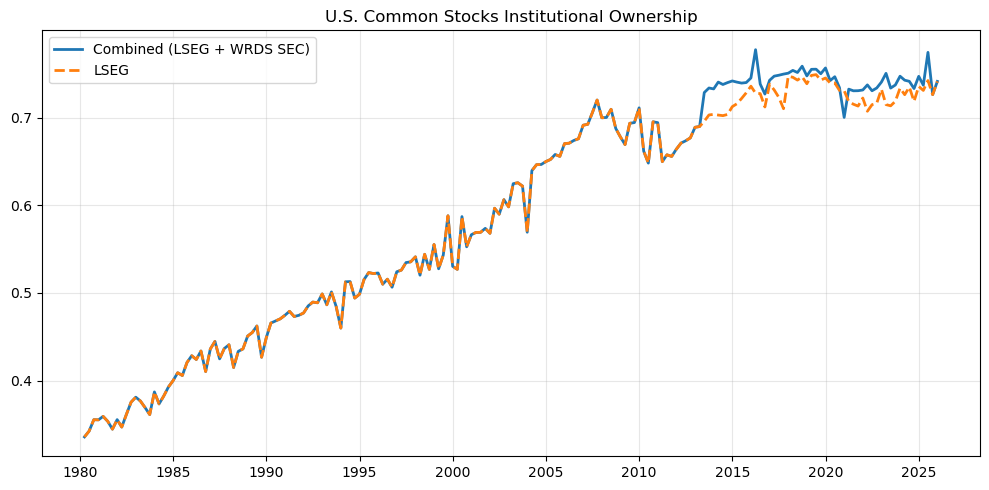

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(aggio.index, aggio['io'],
         label='Combined (LSEG + WRDS SEC)',
         linewidth=2)

plt.plot(aggio_lseg.index, aggio_lseg['io'],
         label='LSEG',
         linewidth=2,
         linestyle='--')

plt.title('U.S. Common Stocks Institutional Ownership')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()